# H2MM on MMFDB with known ground truth

> ⚠️ **Experimental.** ChiSurf's H2MM engine is validated against the reference
> implementation but is still being refined.

Photon-by-photon **H2MM** recovers hidden FRET states from single-molecule
bursts. To *see that it works*, this notebook uses **simulated** data whose
answer we already know:

1. **Simulate** a two-state smFRET experiment with tttrlib — we pick the FRET
   efficiencies and the exchange rate, so the ground truth is defined.
2. **Store** the simulated measurement in **MMFDB** (it behaves like any real
   file) and get a handle back.
3. **Recover** the states with H2MM and check them against the truth.
4. Compare the **analysis modes** (engines, model-selection criteria) and the
   **static vs dynamic** case.

Everything runs through the same `BurstWorkflow` used for real data.

In [1]:
%matplotlib inline
import logging, warnings
for _noisy in ("numexpr", "mmfdb"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

## 1. Simulate a dataset with known ground truth

`wf.simulate` generates diffusing single molecules with tttrlib's confocal
simulator. We ask for **two states at E = 0.25 and E = 0.75** that interconvert
(`exchange_rate`), then it stores the result in MMFDB and returns a handle plus
the `truth` we defined.

In [2]:
wf = BurstWorkflow.demo()

sim = wf.simulate(fret=(0.25, 0.75), exchange_rate=2.0, seed=12345)
print("Ground-truth FRET states:", sim.truth.fret.tolist())
print("Stored in MMFDB with handle:", sim.handle)

Ground-truth FRET states: [0.25, 0.75]
Stored in MMFDB with handle: bc03ac72-2cdd-4d97-b95b-bbb6f984759f


## 2. Find the bursts (straight from the MMFDB handle)

The setup that matches the simulation (`green` = channel 0, `red` = channel 1)
comes back on `sim.setup`, so selection is one line.

In [3]:
bursts = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20)
print(bursts)

<Bursts: 1345 bursts from simulation.spc>


## 3. Recover the states with H2MM and check the truth

H2MM scans 1–3 states, picks the best by BIC, and reports the per-state FRET.
The dashboard shows the four standard H2MM views: recovered **states**, the
**model-selection** curves, the **transition-rate** matrix, and the **dwell-time**
distributions.

Best model: 2 state(s) (engine=em, criterion=bic)
  state 0: FRET E = 0.25, population = 49%
  state 1: FRET E = 0.75, population = 51%

Ground truth was: [0.25, 0.75]


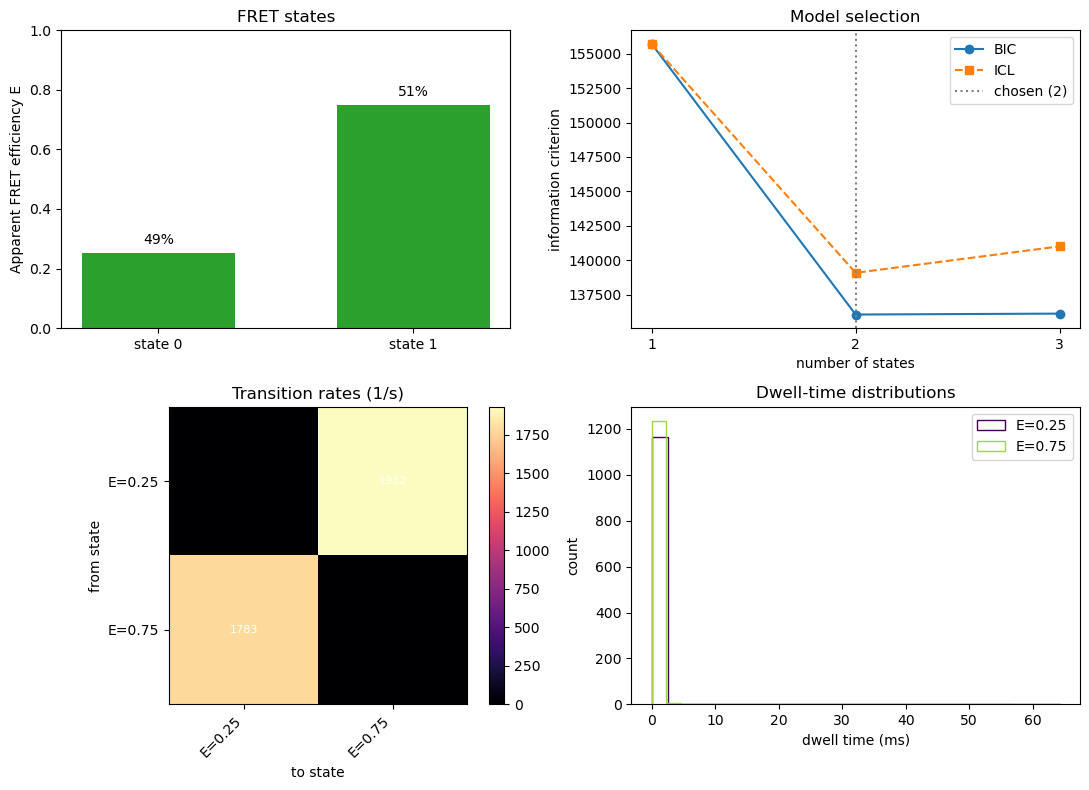

In [4]:
h2mm = bursts.h2mm(states=(1, 2, 3))
print(h2mm.summary())
print("\nGround truth was:", np.round(sim.truth.fret, 2).tolist())

h2mm.plot()
plt.show()

The recovered efficiencies land on the values we simulated — H2MM found the
right answer on data where we know it.

## 4. Analysis modes

**Model-selection criterion.** H2MM chooses the number of states by minimising
an information criterion. `BIC` and `ICL` are both plotted above; here they are
compared directly — both should prefer two states.

In [5]:
for criterion in ("bic", "icl"):
    h = bursts.h2mm(states=(1, 2, 3), criterion=criterion)
    print(f"{criterion.upper():4s} -> {h.n_states} states, E = {np.round(np.sort(h.fret), 2).tolist()}")

BIC  -> 2 states, E = [0.25, 0.75]


ICL  -> 2 states, E = [0.25, 0.75]


**Compute engine.** The exact `em` engine is the default; `em-float32` and the
trained `surrogate` engines exist to speed up **large** datasets (many bursts /
states) at a small precision cost. On this small example they are numerically
equivalent — both recover the same states:

In [6]:
for engine in ("em", "em-float32"):
    h = bursts.h2mm(states=(2,), engine=engine)
    print(f"{engine:11s} -> E = {np.round(np.sort(h.fret), 3).tolist()}")

em          -> E = [0.253, 0.75]

em-float32  -> E = [0.253, 0.75]


## 5. Static vs dynamic molecules

The same two states can be **static** (no exchange) or **dynamic** (converting
during a burst). Burst Variance Analysis / proximity-ratio histograms tell them
apart: static molecules give **two separated peaks**; dynamic ones are pulled
toward the middle. We simulate both and histogram the per-burst FRET.

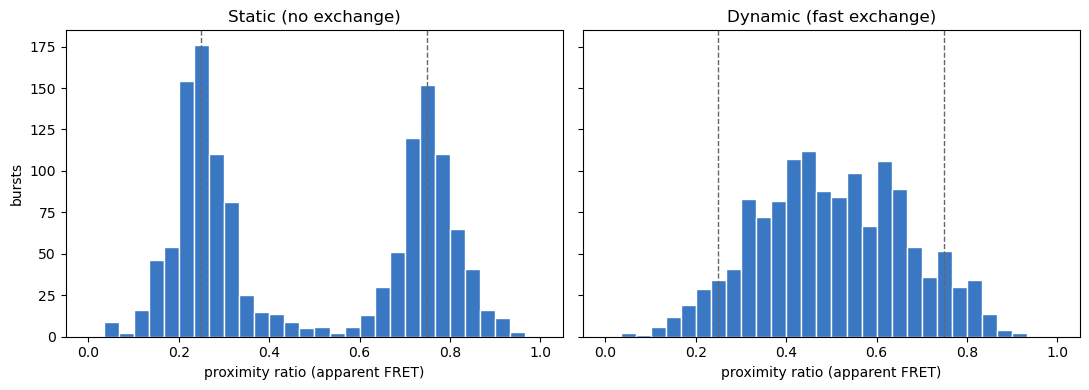

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
bins = np.linspace(0, 1, 31)
for ax, (rate, title) in zip(axes, [(0.0, "Static (no exchange)"),
                                     (5.0, "Dynamic (fast exchange)")]):
    s = wf.simulate(fret=(0.25, 0.75), exchange_rate=rate, seed=7)
    pr = wf.select_bursts(s.handle, setup=s.setup, min_photons=20).bva().table["Proximity Ratio Mean"]
    ax.hist(pr.dropna(), bins=bins, color="#3b78c3", edgecolor="white")
    for e in (0.25, 0.75):
        ax.axvline(e, color="0.4", ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("proximity ratio (apparent FRET)")
axes[0].set_ylabel("bursts")
fig.tight_layout()
plt.show()

## 6. Done

We defined the answer, stored simulated photons in MMFDB, and recovered the FRET
states with H2MM — confirming the analysis on data with known truth, and seeing
how the engine, the model-selection criterion, and conformational dynamics each
show up. Swap in a real MMFDB handle (`wf.connect(...)` + `wf.register(file)`)
and the identical H2MM code applies to measured data.

In [8]:
wf.close()
print("Finished.")

Finished.
